# Business Questions

**Dataset**: UK gift shop transactions, 2010–2011.

**Business Questions**:
1. Which products are most popular by quantity sold?
2. Which countries generate the most revenue?

**Useful for**: Shop owner and marketing team to improve sales strategy.

# 01 Load_Cleaning_Preprocessing

Goal: Load data, identify and fix data issues

### Loading

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import ipykernel
e_co_raw_df = pd.read_csv('../data/e-commerce.csv', encoding='latin-1')


### Preprocessing

### Reset 

In [116]:
# Making a copy from the raw dataframe
df=e_co_raw_df.copy()


In [117]:
#Changing the datatype of InvoiceDate from string to usable datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month

In [118]:
# Preparing for country revenue analysis
df['Revenue']=df['Quantity']*df['UnitPrice']

Categorizing non-product descriptions out for further filtering

In [119]:
#Extract all the operational words

#Filtering all the operational words as in free products we find some descriptions are not related to any products
operational_notes = [
    'check',           
    'damages',         
    'damaged',         
    'found',           
    'thrown away',     
    'adjustment',      
    'reverse',            
    'wet',             
    'missing',        
    'test',            
    'smashed',       
    'mailout',         
    'counted',         
    'returned',        
    'put aside',      
    'on cargo',        
    'allocate stock',  
    'push order',     
    'coded as',             
    'taig',            
    'alan hodge',      
    'allocate stock for dotcom',          
]
#Filtering out sales status from operational
sale_notes = [
    'sold as set on dotcom',  'amazon',          
    'amazon sales','ebay','dotcom' 
]
#Filtering out return or refund status from operational
credit_notes=['credit']


In [120]:
#Categorizing them manually

operational_notes.extend(['Crushed', 'incorrect stock entry', 'wrongly coded 20713', 'rusty throw away', 'mixed up', 'faulty', 'label mix up', 'show room', 'broken', 'throw away', '?lost', 'cracked', 'adjust', 'samples', 'water damage', 'mix up with c', 'mouldy, unsaleable', 'incorrectly put back into stock', 'wrong code?', 'wrong code', 'code mix up? 84930', '?display', 'crushed ctn', 'add stock to allocate online', 'website fixed', 'michel oops', 'wrongly coded-23343', 'crushed boxes', "can't find", 'historic computer difference?....se', 'mouldy', '???lost'])

sale_notes.extend(['sold as 1', 'wrongly sold as sets', 'wrongly sold sets', '? sold as sets?', '?sold as sets?', 'sold in set?', 'sold as 22467', 'for online retail orders'])

credit_notes.extend(['wrong barcode (22467)','wrongly sold (22719) barcode', 'wrong barcode','barcode problem', 'wrongly marked. 23343 in box', 'wrongly marked 23343', '20713 wrongly marked', 'wrongly coded 23343', 'wrongly marked', 'wrongly marked carton 22804'])

In [126]:
#key word series 
keywordlist=operational_notes+sale_notes+credit_notes
keywordlist=[re.escape(word) for word in keywordlist]

In [130]:
#Extending the operational list through manaul checking
candidates = df['Description'].str.lower().value_counts()
candidates=candidates[~candidates.index.str.contains('|'.join(keywordlist), case=False, na=False, regex=True)]
print(candidates.head(50))
print(len(candidates))

Description
white hanging heart t-light holder     2369
regency cakestand 3 tier               2200
jumbo bag red retrospot                2159
party bunting                          1727
lunch bag red retrospot                1638
assorted colour bird ornament          1501
set of 3 cake tins pantry design       1473
pack of 72 retrospot cake cases        1385
lunch bag  black skull.                1350
natural slate heart chalkboard         1280
postage                                1252
jumbo bag pink polkadot                1251
heart of wicker small                  1237
jam making set with jars               1229
jumbo storage bag suki                 1214
paper chain kit 50's christmas         1210
jumbo shopper vintage red paisley      1202
lunch bag cars blue                    1197
lunch bag spaceboy design              1192
jam making set printed                 1182
recipe box pantry yellow design        1180
spotty bunting                         1172
lunch bag suki desig

Obeservation: Operational/Sales/Credit notes are not standardized

Action:Clean them in transformation stage

putting all the notes to regex will reduce execution a lot

In [113]:
keys = ['operational_notes', 'sale_notes', 'credit_notes']
values = [operational_notes, sale_notes, credit_notes]

# Direct conversion
notes_dict= dict(zip(keys, values))
for note_names, notes in notes_dict.items():
    print(f'The structure of the  {note_names} is : {notes}')

The structure of the  operational_notes is : ['check', 'damages', 'damaged', 'found', 'thrown away', 'adjustment', 'reverse', 'wet', 'missing', 'test', 'smashed', 'mailout', 'counted', 'returned', 'put aside', 'on cargo', 'allocate stock', 'push order', 'coded as', 'taig', 'alan hodge', 'allocate stock for dotcom', 'Crushed', 'incorrect stock entry', 'wrongly coded 20713', 'rusty throw away', 'mixed up', 'faulty', 'label mix up', 'show room', 'broken', 'throw away', '?lost', 'cracked', 'adjust', 'samples', 'water damage', 'mix up with c', 'mouldy, unsaleable', 'incorrectly put back into stock', 'wrong code?', 'wrong code', 'code mix up? 84930', '?display', 'crushed ctn', 'add stock to allocate online', 'website fixed', 'michel oops', 'wrongly coded-23343', 'crushed boxes', "can't find", 'historic computer difference?....se', 'mouldy', '???lost']
The structure of the  sale_notes is : ['sold as set on dotcom', 'amazon', 'amazon sales', 'ebay', 'dotcom', 'sold as 1', 'wrongly sold as sets

In [ ]:
operational_notes.extend(df[df.index.str.contains('|'.join(operational_notes), case=False, na=False, regex=True)]['Description'].unique().tolist())

Description
had been put aside                     5
taig adjust                            2
rcvd be air temp fix for dotcom sit    1
did  a credit  and did not tick ret    1
mailout                                1
on cargo order                         1
to push order througha s stock was     1
came coded as 20713                    1
alan hodge cant mamage this section    1
allocate stock for dotcom orders ta    1
add stock to allocate online orders    1
found box                              1
amazon adjust                          1
dotcomstock                            1
dotcom adjust                          1
check?                                 1
Name: count, dtype: int64

In [97]:
#Turning all the list into mappable series

a = pd.Series('Operational', index=operational_notes, name='Category')
b= pd.Series('Sales', index=sale_notes, name='Category')
c=pd.Series('Credit', index=credit_notes, name='Category')

In [98]:
#concatening the three series into 1 mappable series
key_series= pd.concat([a, b, c], axis=0)
key_series = key_series[~key_series.index.duplicated(keep='first')]

In [99]:
df['Description_Category']= df['Description'].map(key_series)

In [100]:
print(f'The total number of non_product descriptions against total number of products: {(len(df[df['Description_Category'].notna()])/len(df)) *100} %')
print()
print(f'The distributioni of non-product descriptions :{df['Description_Category'].value_counts()}')

The total number of non_product descriptions against total number of products: 0.0745512622968063 %

The distributioni of non-product descriptions :Description_Category
Operational    345
Sales           49
Credit          10
Name: count, dtype: int64


### Identifying Issues 

In [49]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Revenue,Description_Category
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,15.30,NaN
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34,NaN
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,22.00,NaN
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34,NaN
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,20.34,NaN


Obeservation 1: 84029* variants differ in suffix only — not product variants. description.

Action 1: Prioritize other cleaning issues first 

In [50]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Month,Revenue
count,541909.000000,541909,541909.000000,406829.000000,541909.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,7.553128,17.987795
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,1.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,5.000000,3.400000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,8.000000,9.750000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,11.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,12.000000,168469.600000
std,218.081158,NaN,96.759853,1713.600303,3.509055,378.810824


Observation 1: Quantity and UnitPrice contain negative values 
               and extreme outliers.

Action 1: Filter out negative Quantity and UnitPrice 
          (likely returns/errors) during Cleaning.

Action 2: Note outliers — investigate later if they 
          affect analysis results.

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   InvoiceNo             541909 non-null  str           
 1   StockCode             541909 non-null  str           
 2   Description           540455 non-null  str           
 3   Quantity              541909 non-null  int64         
 4   InvoiceDate           541909 non-null  datetime64[us]
 5   UnitPrice             541909 non-null  float64       
 6   CustomerID            406829 non-null  float64       
 7   Country               541909 non-null  str           
 8   Month                 541909 non-null  int32         
 9   Revenue               541909 non-null  float64       
 10  Description_Category  404 non-null     str           
dtypes: datetime64[us](1), float64(3), int32(1), int64(1), str(5)
memory usage: 43.4 MB


Observation 1: CustomerID has missing values.

Action 1: Explore missing customer patterns before cleaning.

Observation 2: Description has missing values.

Action 1: Explore missing product patterns before cleaning.

Observation 3: InvoiceDate is not datetime.

Action 1: Convert before time analysis.

In [52]:
# To view whether how long does the record spans
df['InvoiceDate'].agg(['min', 'max'])

min   2010-12-01 08:26:00
max   2011-12-09 12:50:00
Name: InvoiceDate, dtype: datetime64[us]

In [53]:
print(e_co_raw_df.shape)  # 應該是 (541909, 8)
print(df.shape)

(541909, 8)
(541909, 11)


### Cleaning

Since the project's aim is not calculating the return rate of a product and identify reasons of return.

We will remove all the negative values 

In [101]:
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] >= 0)]

df[df['Description_Category'].notna()]['Quantity'].sum() / df_clean['Quantity'].sum()

np.float64(-0.0075052389348202846)

!

In [ ]:
df_clean= df_clean[df_clean['Description_Category'].isna()]
df_clean=df_clean[df_clean['Description']!="?"]

In [55]:
# Calculating and comparing the missing ratio of CustomerID and Description respectively
Missing_ratio_CustomerID=(df_clean['CustomerID'].isna().sum())/len(df_clean['CustomerID'])
Missing_ratio_Description=(df_clean['Description'].isna().sum())/len(df_clean['Description'])
print("The missing report:")
print(f"The number of missing records of CustomerID: {df_clean['CustomerID'].isna().sum()}")
print(f"The number of missing records of Description: {df_clean['Description'].isna().sum()}")
print()

print(f'The percentage of missing CustomerID: {Missing_ratio_CustomerID*100}')
print(f'The percentage of missing Description: {Missing_ratio_Description*100}')

The missing report:
The number of missing records of CustomerID: 133246
The number of missing records of Description: 592

The percentage of missing CustomerID: 25.08537756273886
The percentage of missing Description: 0.11145207748931604


Observation 1: ~25% CustomerID missing 

Action 1: Filter and inspect patterns

Action 2: Compare later only if the missing group shows a clear clue.

Observation 2: ~0.111% Description missing

Actions: Same approach as observation 1

#### CustomerID_NaN

In [56]:
#Filtering out all the 'CustomerID' missing records in.
CustomerID_NaN=df_clean[df_clean['CustomerID'].isna()]
CustomerID_NaN.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Revenue,Description_Category
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,12,0.00,NaN
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,12,2.51,NaN
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,12,5.02,NaN
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,12,3.40,NaN
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,12,3.32,NaN


Obeservation 1: The first record have both description and customerID as NaN. Whereas unitprice is 0.0.

Action 1: Identify if missing rows of description is the subset of missing rows of CustomerID

Observation 2: The 5 records are on the same day

Action 1: Make a line chart of months especially december.


##### Figure 1: "Top 5 invoice count for missing CustomerID"

Text(0, 0.5, 'Number of Invoices')

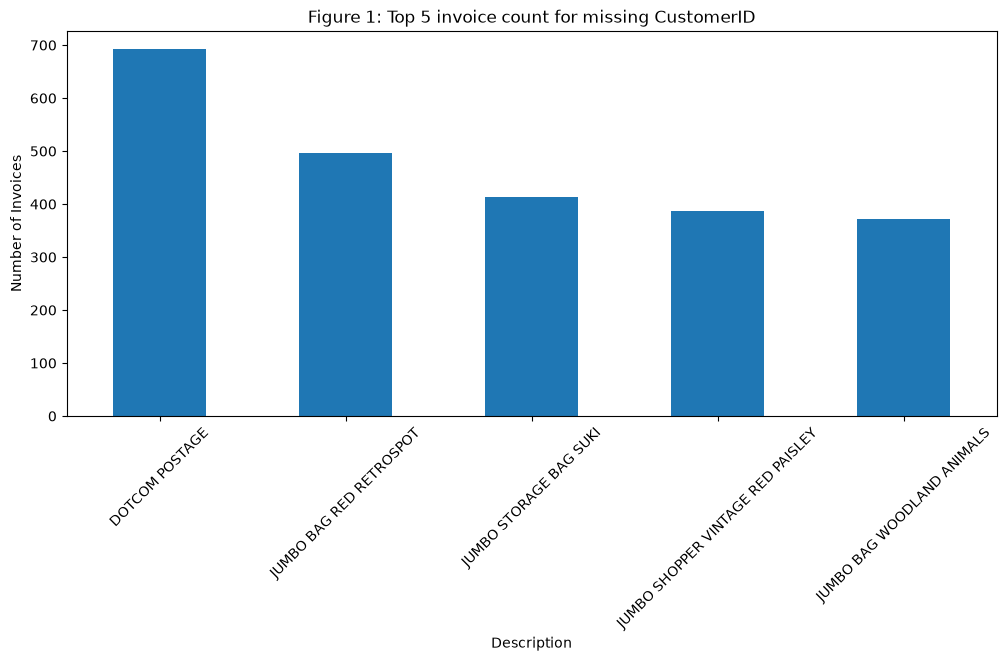

In [57]:
plt.figure(figsize=(12, 5))
plt.tight_layout()

CustomerID_NaN['Description'].value_counts().sort_values(ascending=False).head().plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Figure 1: Top 5 invoice count for missing CustomerID")
plt.xlabel("Description")
plt.ylabel("Number of Invoices")

Observation 1: The brand "JUMBO" has occupied 4 seats of the top 5 records

Action 1: See whether Jumbo brand has the highest number of rows in CustomerID_NaN.

Obeservation 2: DOTCOM POSTAGE is most popular 

Action 1: Calculate the number of invoice of Dotcom against total missing records

In [58]:
dotcom_over_total=len(CustomerID_NaN[CustomerID_NaN['Description']=='DOTCOM POSTAGE'])/len(CustomerID_NaN)
print(f' The percentage of records that DOTCOM POSTAGE has occcupied is: {dotcom_over_total*100} %')

 The percentage of records that DOTCOM POSTAGE has occcupied is: 0.5193401678099155 %


Obeservation 1: DOTCOM POSTAGE is most popular but does not occupy high percentage in missing records.

Action 1: Calculate the statistics of number of records 

In [59]:
print(f'The mean, median and standard deviation of number of records in each product/ description')
print(f'The mean: {CustomerID_NaN['Description'].value_counts().mean()}')
print(f'The median: {CustomerID_NaN['Description'].value_counts().median()}')
print(f'The standard deviation {CustomerID_NaN['Description'].value_counts().std()}')


The mean, median and standard deviation of number of records in each product/ description
The mean: 38.970035252643946
The median: 22.0
The standard deviation 50.16360229175753


Observation 1: The number of records in each product are  right skewed and widely disperesed. First, the mean is greater than the median. Second, the standard deviation is greater than the mean.
 
Action 1: Identify outliers and decision on whether to clean it or not

In [60]:
No_Jumbo_records=len(CustomerID_NaN[CustomerID_NaN['Description'].str.contains('JUMBO')])

print(f'The percentage of number of JUMBO products {No_Jumbo_records/len(CustomerID_NaN)*100}')

The percentage of number of JUMBO products 4.053404980262072


Obeservation: JUMBO brand does not occupies most records in the number of records.

##### Analyzing the spending pattern of CustomerID= NaN users by quantity instead of number of records

In [61]:
Description_Quantity=CustomerID_NaN.groupby('Description')['Quantity'].sum()
Description_Quantity=Description_Quantity.sort_values(ascending=False)

In [62]:
Description_Quantity.head()

Description
CHARLOTTE BAG SUKI DESIGN          9177
POPCORN HOLDER                     5830
RED RETROSPOT CHARLOTTE BAG        4962
WOODLAND CHARLOTTE BAG             4073
PAPER CHAIN KIT 50'S CHRISTMAS     3738
Name: Quantity, dtype: int64

Obeservation： An unknown product has a quantity of 8112

Action： Inspect patterns before filtering out


In [63]:
CustomerID_NaN[CustomerID_NaN['Description']=='?']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Revenue,Description_Category


In [64]:
len(CustomerID_NaN[CustomerID_NaN['Description']=='?'])

0

In [65]:
question_marklist=CustomerID_NaN[CustomerID_NaN['Description']=='?']['StockCode'].unique().tolist()
code_of_question_=CustomerID_NaN[(CustomerID_NaN['StockCode'].isin(question_marklist))&(CustomerID_NaN['Description']!='?')]

In [66]:
not_zero_series=code_of_question_.groupby('StockCode')['UnitPrice'].mean()

In [67]:
not_zero_series.head()

Series([], Name: UnitPrice, dtype: float64)

In [68]:
is_zero_dict={}
question_marklist=list(set(question_marklist))
for code in question_marklist:
    is_zero_dict[code]="NO"

for key in is_zero_dict.keys():
    mask=(not_zero_series.index==key)
    if mask.any()==True:
        is_zero_dict[key]="YES"
print(is_zero_dict)

{}


Obeservation: Therefore all the stockcodes in with question mark description does not exists as there correspond stock codse returns unitprice greater than 0

Action: Filter out all the ? description

##### Comparison between figure 1 and 2

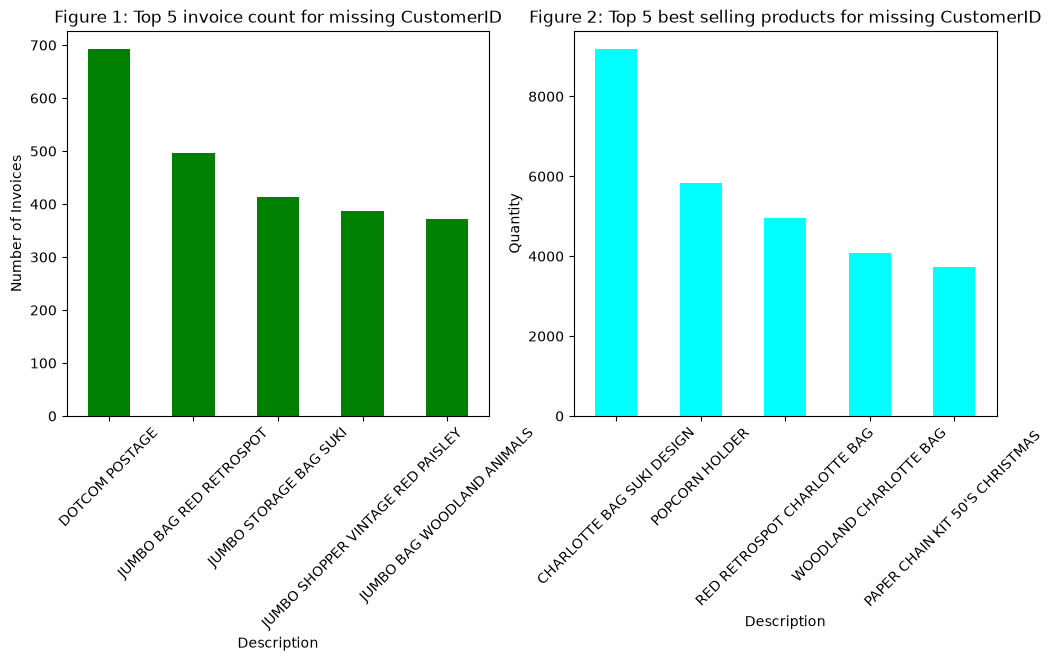

In [69]:
fig, ax=plt.subplots(1,2, figsize=(12,5))
CustomerID_NaN['Description'].value_counts().sort_values(ascending=False).head().plot(kind='bar', ax=ax[0], color='green')
ax[0].set_title("Figure 1: Top 5 invoice count for missing CustomerID")
ax[0].set_xlabel("Description")
ax[0].set_ylabel("Number of Invoices")
ax[0].tick_params(axis='x', rotation=45)  # ✅ 精準控制 ax[0]

Description_Quantity.head().plot(kind='bar', ax=ax[1], color='cyan')
ax[1].set_title('Figure 2: Top 5 best selling products for missing CustomerID')
ax[1].set_xlabel('Description')
ax[1].set_ylabel('Quantity')
ax[1].tick_params(axis='x', rotation=45)  # ✅ 精準控制 ax[1]
plt.show()

Obeservation 1: When switching from counting invoice to quantity the top 5 laterally changed

Observation 2: JUMBO no longer seats in the top 5

action 1: Compare the percentage occupied by Jumbo agains the top 5

Observation 3: Charlotte has occuppied 3 seats in the top 3

In [70]:
print('JUMBO brand family against Top1 in terms of quantity')
tp1=str(Description_Quantity.index[0])
Quantity_of_tp1=Description_Quantity[tp1]
print(f"The percentile of {tp1} against the total quantity :{(Quantity_of_tp1/Description_Quantity.sum())*100}")

jumbo_quantity=Description_Quantity[Description_Quantity.index.str.contains('JUMBO')].sum()
print(f"The percentile of JUMBO brand family against the total quantity: {jumbo_quantity/CustomerID_NaN['Quantity'].sum()*100}")
No_Jumbo_records=len(CustomerID_NaN[CustomerID_NaN['Description'].str.contains('JUMBO')])

print(f'The percentage of number of JUMBO products {No_Jumbo_records/len(CustomerID_NaN)*100}')


JUMBO brand family against Top1 in terms of quantity
The percentile of CHARLOTTE BAG SUKI DESIGN against the total quantity :2.124649827518348
The percentile of JUMBO brand family against the total quantity: 5.227815370836446
The percentage of number of JUMBO products 4.053404980262072


Observation 1: JUMBO brand family is still occupies higher amount of quantity then CHARLOTTE BAG SUKI DESIGN

Obeservation 2: The percentage of JUMBO family rises when using quantity.

In [71]:
jumbo_quantity=CustomerID_NaN[CustomerID_NaN['Description'].str.contains('JUMBO')]['Quantity'].sum()
print(f"The percentile of jumbo against the total number of customerIDs: {jumbo_quantity/CustomerID_NaN['Quantity'].sum()*100}")



The percentile of jumbo against the total number of customerIDs: 5.227815370836446


In [72]:
#Std of quantity
print(f'The mean, median and the standard deviation of the quantity of each product')
print(f'The median: {Description_Quantity.mean()}')
print(f'The mean: {Description_Quantity.median()}')
print(f'The standard deviation {Description_Quantity.std()}')
print()
print('_'*100)
print(f'The mean, median and standard deviation of number of records in each product/ description')
print(f'The mean: {CustomerID_NaN['Description'].value_counts().mean()}')
print(f'The median: {CustomerID_NaN['Description'].value_counts().median()}')
print(f'The standard deviation {CustomerID_NaN['Description'].value_counts().std()}')


The mean, median and the standard deviation of the quantity of each product
The median: 126.88895417156287
The mean: 42.0
The standard deviation 329.2493854347961

____________________________________________________________________________________________________
The mean, median and standard deviation of number of records in each product/ description
The mean: 38.970035252643946
The median: 22.0
The standard deviation 50.16360229175753


Observation 1: Quantity has a left skewed and widely dispered behaviour due to median > mean and std > mean.

Action: Identify outliers and decide whether to clean or not



#### Description sheet

In [73]:
#The filtering out the missing description
Description_NaN=df_clean[df_clean['Description'].isna()]

In [74]:
#Investigating whether description NaN records are the subsets of CustomerID NaNs
Description_NaN.isna().sum()

InvoiceNo                 0
StockCode                 0
Description             592
Quantity                  0
InvoiceDate               0
UnitPrice                 0
CustomerID              592
Country                   0
Month                     0
Revenue                   0
Description_Category    592
dtype: int64

Obeservation 1: Descriptions NaNs are the subset of CustomerID as all descriptions have CustomerID as NaN

Action 2: Compare line chart of missing descriptions and customerID to find their relations

In [75]:
print(f'The number of description NaN records is zero :{len(Description_NaN[Description_NaN['UnitPrice']==0.0])}')

The number of description NaN records is zero :592


In [76]:
free_products=df_clean[(~df_clean['Description'].isna()) & (df_clean['UnitPrice']==0.0)]
free_products_name=free_products['Description'].unique().tolist()
free_products_name[0:10]

['ROUND CAKE TIN VINTAGE GREEN',
 'CREAM SWEETHEART LETTER RACK',
 'ZINC WILLIE WINKIE  CANDLE STICK',
 'BOX OF 24 COCKTAIL PARASOLS',
 'DOORMAT ENGLISH ROSE ',
 'DOORMAT 3 SMILEY CATS',
 'GREEN REGENCY TEACUP AND SAUCER',
 'FRENCH BLUE METAL DOOR SIGN 7',
 'FRENCH BLUE METAL DOOR SIGN 5',
 'FRENCH BLUE METAL DOOR SIGN 6']

Observation: As free products >1 filling those description NaN and Unitprice=0.0 with these would mask its actual quantity.

Action: drop Description NaN.

In [102]:
df_clean=df_clean.dropna(subset=['Description'])

In [103]:
print(free_products['Description'].str.isupper().value_counts())

Description
True     404
False     70
Name: count, dtype: int64


In [82]:

strange = free_products[free_products['Description'].str.islower()]
print(strange['Description'].value_counts())

Description
had been put aside                     5
taig adjust                            2
rcvd be air temp fix for dotcom sit    1
did  a credit  and did not tick ret    1
mailout                                1
on cargo order                         1
to push order througha s stock was     1
came coded as 20713                    1
alan hodge cant mamage this section    1
allocate stock for dotcom orders ta    1
add stock to allocate online orders    1
found box                              1
amazon adjust                          1
dotcomstock                            1
dotcom adjust                          1
check?                                 1
Name: count, dtype: int64


New observation: Operational, sales and credit type description exists 

Obeservation: The free product descriptions that are not in capital are often associated with non-product name descriptions.

Action 1: Categorize them and assign to a new column named a ['Description_Category'] column.

In [79]:
free_products[free_products['Description'].str.isupper()]['Description']

9302             ROUND CAKE TIN VINTAGE GREEN
14335            CREAM SWEETHEART LETTER RACK
14336        ZINC WILLIE WINKIE  CANDLE STICK
14337             BOX OF 24 COCKTAIL PARASOLS
14338                   DOORMAT ENGLISH ROSE 
                         ...                 
503634                                 AMAZON
519355                                 AMAZON
521408    FRIDGE MAGNETS LES ENFANTS ASSORTED
521417               CLASSIC GLASS COOKIE JAR
521436                         DOTCOM POSTAGE
Name: Description, Length: 404, dtype: str

Observation: Operational type descriptions can still be capital

Action: Categorize them and assign to a new column named a [Is Operational] column.

Text(619.9949494949494, 0.5, 'Number of Records')

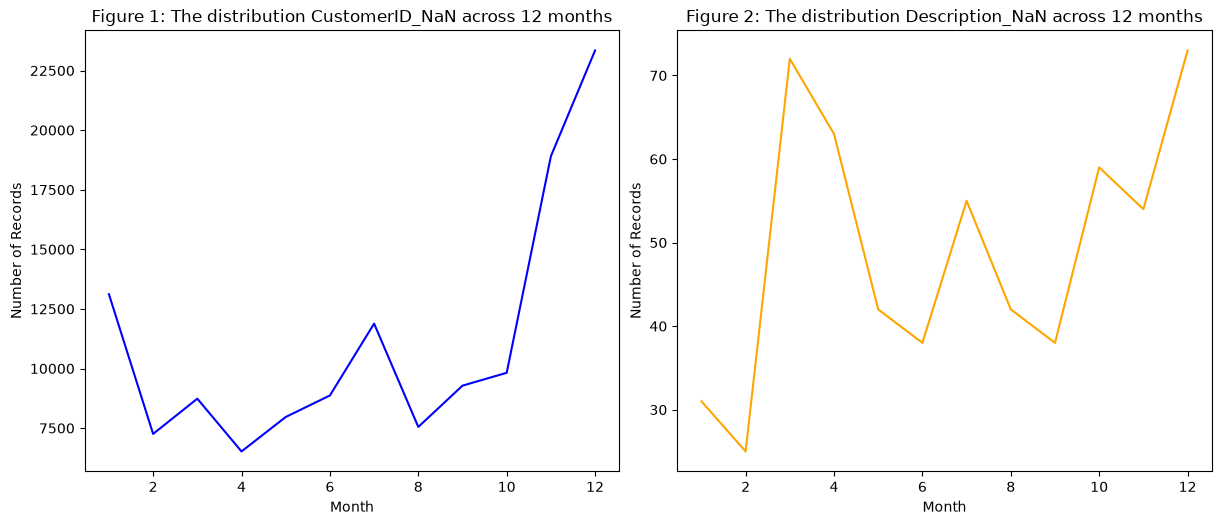

In [83]:
fig,ax=plt.subplots(1,2,figsize=(12, 5))
plt.tight_layout()
CustomerID_NaN['Month'].value_counts().sort_index().plot(kind='line', color='blue', ax=ax[0])
ax[0].set_title("Figure 1: The distribution CustomerID_NaN across 12 months")
ax[0].set_xlabel("Month")
ax[0].set_ylabel("Number of Records")

Description_NaN['Month'].value_counts().sort_index().plot(kind='line', color='orange', ax=ax[1])
ax[1].set_title("Figure 2: The distribution Description_NaN across 12 months")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Number of Records")

Obeservation 1: Strong trend of increasing missing records are spotted from october to december (Fig 1).


Obeservation 2: (Fig 2) 2 strong trend one between Feberuary and April and another one from october to december.

Obeservation 3: (Figure 1 & 2) both spike at october and december 

action: Scatter plot to prove whether the claim of observation 3 is correct or not


**Self notes: However the dataset start from 2010 december it would added to 2011 december which masks the number of customers in december (Advanced data question)**

# 02 Transformation

# 03 Analyse

# 04 Insight and Conclusion